In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import random
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("fake_job_postings.csv")
print(df.shape)
df.head()

(17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


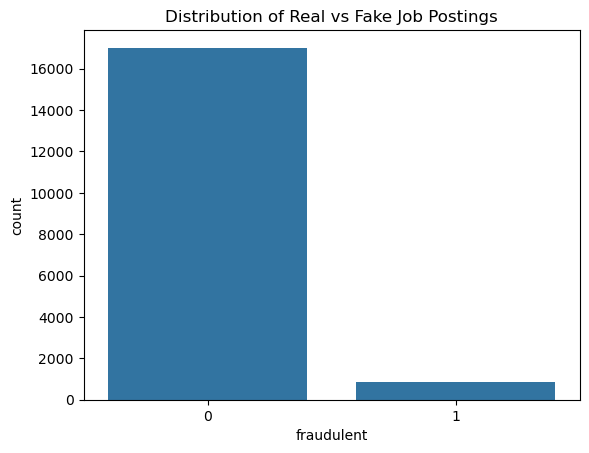

fraudulent
0    17014
1      866
Name: count, dtype: int64
salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
job_id                     0
telecommuting              0
has_questions              0
has_company_logo           0
title                      0
fraudulent                 0
dtype: int64


In [3]:
sns.countplot(x='fraudulent', data=df)
plt.title("Distribution of Real vs Fake Job Postings")
plt.show()

print(df['fraudulent'].value_counts())
print(df.isnull().sum().sort_values(ascending=False))

In [4]:
df['text'] = (
    df['title'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['requirements'].fillna('') + ' ' +
    df['company_profile'].fillna('')
)

In [5]:
random.seed(42)
np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['fraudulent'],
    test_size=0.2,
    random_state=42,
    stratify=df['fraudulent']
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 14304 | Test size: 3576


In [6]:
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

In [7]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='liblinear',
    class_weight='balanced'   # fixes class imbalance
)
model.fit(X_train_vec, y_train)
print("Model trained successfully.")

Model trained successfully.


In [8]:
preds = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=['Real', 'Fake']))

Accuracy: 0.9678411633109619

Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.97      0.98      3403
        Fake       0.62      0.87      0.72       173

    accuracy                           0.97      3576
   macro avg       0.81      0.92      0.85      3576
weighted avg       0.98      0.97      0.97      3576



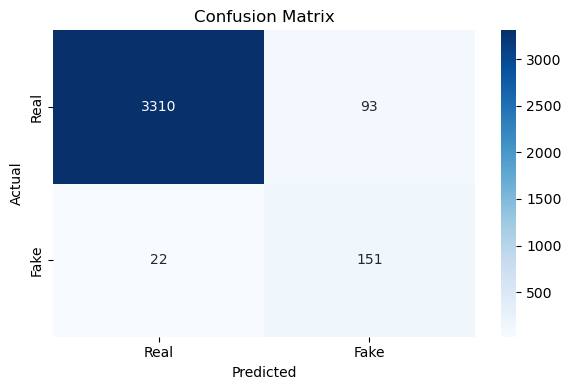

In [9]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [10]:
joblib.dump(model,      "fake_job_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
print("Model and vectorizer saved.")

Model and vectorizer saved.


In [1]:
import os
print(os.getcwd())

C:\Users\prabh\Mini-Project
